# 06 Training

This notebook trains the final production model using the selected features and the tuned parameters written back into `params.yaml`.

Outputs:
- final model artifact
- metrics JSON
- test prediction CSV


## Research Paper Alignment

Training stays separate from the research benchmark on purpose. The deployable model is optimized for reproducibility and serving, while the research stage explores broader hybrid and regime-sensitive ideas.


In [1]:
from pathlib import Path
import json
import os
import subprocess
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import yaml

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "params.yaml").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
os.chdir(PROJECT_ROOT)

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["figure.dpi"] = 130

ASSET_DIR = PROJECT_ROOT / "presentation" / "figures"
ASSET_DIR.mkdir(parents=True, exist_ok=True)

def read_json(path: str):
    return json.loads(Path(path).read_text(encoding="utf-8"))

params = yaml.safe_load(Path("params.yaml").read_text(encoding="utf-8"))


In [2]:
params["training"]


{'train_data_path': 'dvc_pipeline/data/features/train.csv',
 'test_data_path': 'dvc_pipeline/data/features/test.csv',
 'full_data_path': 'dvc_pipeline/data/features/feature_dataset.csv',
 'feature_columns_path': 'dvc_pipeline/data/features/selected_feature_columns.json',
 'date_column': 'Date',
 'target_column': 'Price',
 'test_size': 252,
 'model_name': 'ridge',
 'random_state': 42,
 'cv_splits': 5,
 'n_iter': 30,
 'n_jobs': -1,
 'fixed_params': {'model__alpha': 0.2196385372416547},
 'output_model_path': 'dvc_pipeline/models/final_model.joblib',
 'metrics_path': 'dvc_pipeline/reports/training_metrics.json',
 'predictions_path': 'dvc_pipeline/reports/test_predictions.csv'}

In [3]:
subprocess.run([sys.executable, "dvc_pipeline/src/train_model.py"], check=True)


CompletedProcess(args=['c:\\aditi\\.venv\\Scripts\\python.exe', 'dvc_pipeline/src/train_model.py'], returncode=0)

In [4]:
metrics = read_json(params["training"]["metrics_path"])
pred_df = pd.read_csv(params["training"]["predictions_path"])
pred_df["Date"] = pd.to_datetime(pred_df["Date"])

metrics, pred_df.head()


({'model_name': 'ridge',
  'selection_mode': 'fixed_params',
  'best_cv_rmse': None,
  'best_params': {'model__alpha': 0.2196385372416547},
  'train_metrics': {'rmse': 0.17190132155637206,
   'mae': 0.05270737564270163,
   'mape': 0.000620580049950716,
   'r2': 0.9999781233214636},
  'test_metrics': {'rmse': 0.029965815851163664,
   'mae': 0.015143377816328898,
   'mape': 0.0001325401350171341,
   'r2': 0.9999937510939204},
  'feature_count': 14,
  'train_rows': 1982,
  'test_rows': 252,
  'full_rows': 2234,
  'output_model_path': 'dvc_pipeline\\models\\final_model.joblib'},
         Date  actual   predicted
 0 2023-12-29  136.37  136.367474
 1 2024-01-02  136.37  136.372309
 2 2024-01-03  144.16  143.946278
 3 2024-01-04  142.95  142.967979
 4 2024-01-05  141.45  141.500868)

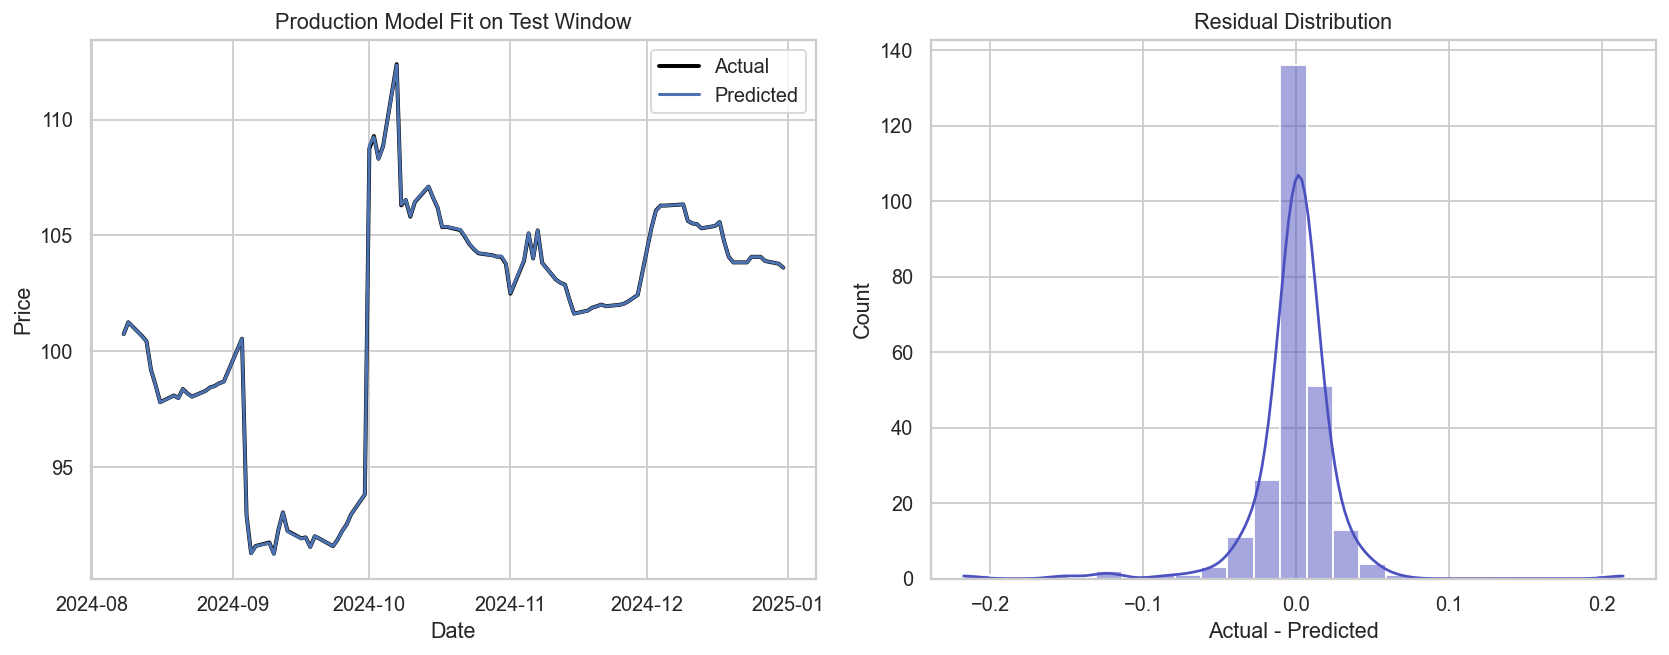

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))

trace_df = pred_df.tail(100)
sns.lineplot(data=trace_df, x="Date", y="actual", ax=axes[0], label="Actual", linewidth=2.2, color="black")
sns.lineplot(data=trace_df, x="Date", y="predicted", ax=axes[0], label="Predicted", linewidth=1.7)
axes[0].set_title("Production Model Fit on Test Window")
axes[0].set_ylabel("Price")

residuals = pred_df["actual"] - pred_df["predicted"]
sns.histplot(residuals, bins=25, kde=True, ax=axes[1], color="#4c51bf")
axes[1].set_title("Residual Distribution")
axes[1].set_xlabel("Actual - Predicted")

fig.tight_layout()
fig.savefig(ASSET_DIR / "10_production_fit.png", bbox_inches="tight")
plt.show()
